# Notebook 02 — EDA: Feature Quality & Sanity Checks (ML Dataset)

## Purpose
This notebook validates the ML feature dataset created by the pipeline (`src/run_features.py`).

Check:
- dataset size and date coverage
- feature ranges and distributions (sanity checks)
- correlations between features
- potential outliers
- target distribution (next-month returns)

**ML design (current):**
- Target: next-month return (regression)
- Features: lagged returns, volatility, RSI
- Train: 2015–2024
- Test: 2025 (hold-out)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load ML datasets

Load:
- ML training table (2015–2024)
- ML test table (2025)

Format:
- index: (date, ticker)
- columns: features + target

In [3]:
ML_TRAIN_PATH = "../data/processed/ml_train_2015_2024.parquet"
ML_TEST_PATH = "../data/processed/ml_test_2025.parquet"

ml_train = pd.read_parquet(ML_TRAIN_PATH)
ml_test = pd.read_parquet(ML_TEST_PATH)

print("Loaded ML datasets:")
print("ml_train:", ml_train.shape)
print("ml_test:", ml_test.shape)

print("\nIndex names:", ml_train.index.names)
print("Columns:", list(ml_train.columns))
ml_train.head()

Loaded ML datasets:
ml_train: (10421, 7)
ml_test: (1091, 7)

Index names: ['date', 'ticker']
Columns: ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_3m', 'rsi_14m', 'y_next_1m']


ret_1m    ret_3m    ret_6m   ret_12m    vol_3m  \
date       ticker                                                     
2016-01-31 AAL.L  -0.267222 -0.456435 -0.673880 -0.747123  0.145678   
           ABF.L  -0.057462  0.000670  0.164137  0.046446  0.050880   
           ADM.L   0.023442  0.104528  0.196485  0.262395  0.035685   
           ALW.L   0.010831  0.128415  0.066562  0.085298  0.050328   
           ANTO.L -0.075271 -0.060836 -0.319339 -0.372519  0.066082   

                     rsi_14m  y_next_1m  
date       ticker                        
2016-01-31 AAL.L   48.662992   0.730943  
           ABF.L   62.816990   0.081270  
           ADM.L   76.939197  -0.023675  
           ALW.L   69.699537   0.015928  
           ANTO.L  73.994611   0.299316

## 2. Identify feature columns and target column

We programmatically select:
- feature columns: starting with `ret_`, `vol_`, `rsi_`
- target column: starting with `y_next`

In [4]:
feature_cols = [c for c in ml_train.columns if c.startswith(("ret_", "vol_", "rsi_"))]
target_cols = [c for c in ml_train.columns if c.startswith("y_next")]

print("Feature columns:", feature_cols)
print("Target columns:", target_cols)

assert len(target_cols) == 1, f"Expected 1 target column, got {target_cols}"
target_col = target_cols[0]

Feature columns: ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_3m', 'rsi_14m']
Target columns: ['y_next_1m']


## 3. Basic sanity checks

We confirm:
- no missing values in training table (after preprocessing dropna)
- RSI in [0, 100]
- volatility non-negative
- feature magnitudes are plausible for monthly returns

In [5]:
# Missing values
print("Missing values (train):", int(ml_train[feature_cols + [target_col]].isna().sum().sum()))
print("Missing values (test):", int(ml_test[feature_cols + [target_col]].isna().sum().sum()))

# RSI range check (if present)
rsi_cols = [c for c in feature_cols if c.startswith("rsi_")]
if rsi_cols:
    rsi_min = ml_train[rsi_cols].min().min()
    rsi_max = ml_train[rsi_cols].max().max()
    print(f"RSI range (train): {rsi_min:.2f} -> {rsi_max:.2f}")
else:
    print("No RSI columns found.")

# Volatility check
vol_cols = [c for c in feature_cols if c.startswith("vol_")]
if vol_cols:
    vol_min = ml_train[vol_cols].min().min()
    print(f"Volatility min (train): {vol_min:.6f} (should be >= 0)")

Missing values (train): 0
Missing values (test): 0
RSI range (train): 0.00 -> 99.34
Volatility min (train): 0.000000 (should be >= 0)


## 4. Summary statistics (train vs test)

We compute descriptive statistics for features and target to ensure:
- train and test distributions are not wildly inconsistent due to preprocessing issues

In [6]:
desc_train = ml_train[feature_cols + [target_col]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])
desc_test = ml_test[feature_cols + [target_col]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])

print("Train summary stats:")
display(desc_train)

print("Test summary stats:")
display(desc_test)

Train summary stats:


,ret_1m,ret_3m,ret_6m,ret_12m,vol_3m,rsi_14m,y_next_1m
count,10421.000000,10421.000000,10421.000000,10421.000000,10421.000000,10421.000000,10421.000000
mean,0.006693,0.019581,0.038681,0.075685,0.068094,54.791689,0.007655
std,0.082540,0.139175,0.201599,0.308088,0.049253,13.579885,0.082322
min,-0.563037,-0.655840,-0.710559,-0.835931,0.000000,0.000000,-0.563037
1%,-0.201480,-0.322550,-0.417618,-0.506543,0.006973,22.436178,-0.198729
5%,-0.116553,-0.190960,-0.262481,-0.347080,0.014671,33.750157,-0.114989
50%,0.006416,0.016587,0.028703,0.050041,0.057107,54.294150,0.007053
95%,0.129125,0.241365,0.354400,0.542549,0.157314,77.866682,0.129962
99%,0.231786,0.397233,0.630187,1.068474,0.243620,86.631967,0.231786
max,0.838236,1.751487,1.993333,3.894578,0.580961,99.336067,0.838236


Test summary stats:


,ret_1m,ret_3m,ret_6m,ret_12m,vol_3m,rsi_14m,y_next_1m
count,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000
mean,0.016832,0.048263,0.086437,0.144878,0.062934,56.555884,0.014259
std,0.074682,0.143345,0.215791,0.335128,0.039525,12.930973,0.075077
min,-0.289319,-0.392953,-0.559222,-0.495129,0.001616,0.000000,-0.289319
1%,-0.147326,-0.263716,-0.296645,-0.359005,0.008142,29.549212,-0.171641
5%,-0.094128,-0.159997,-0.190856,-0.280917,0.016295,37.229434,-0.097317
50%,0.013379,0.038893,0.054062,0.085905,0.056256,55.814329,0.010144
95%,0.141651,0.292126,0.451203,0.751640,0.136328,77.148999,0.134841
99%,0.226618,0.522564,0.804092,1.233923,0.195987,87.937861,0.226618
max,0.430348,0.783444,1.522789,2.861538,0.367931,97.269277,0.430348


## 5. Feature distributions (train)

Plot histograms for each feature to inspect:
- skewness and heavy tails
- outliers
- whether values are plausible

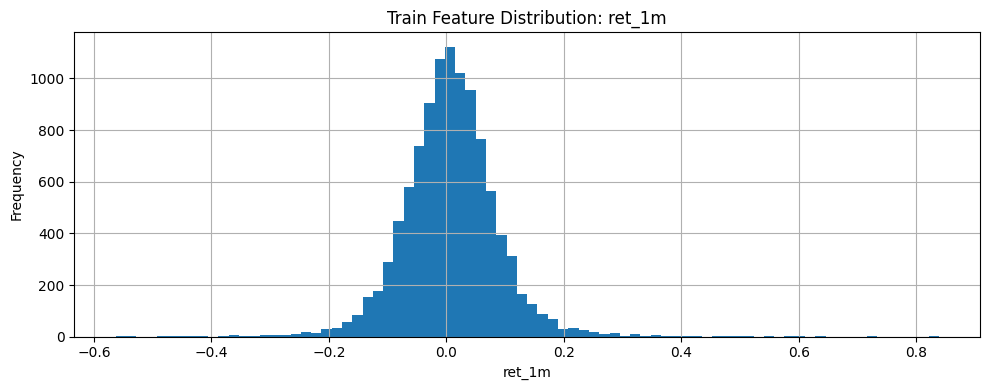

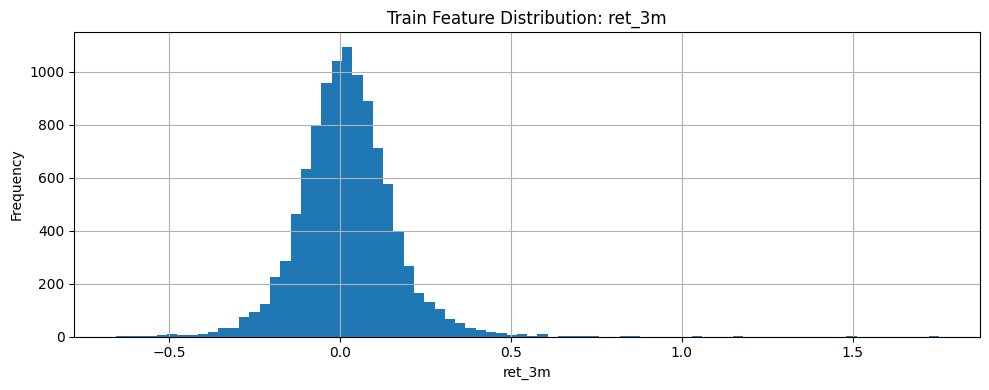

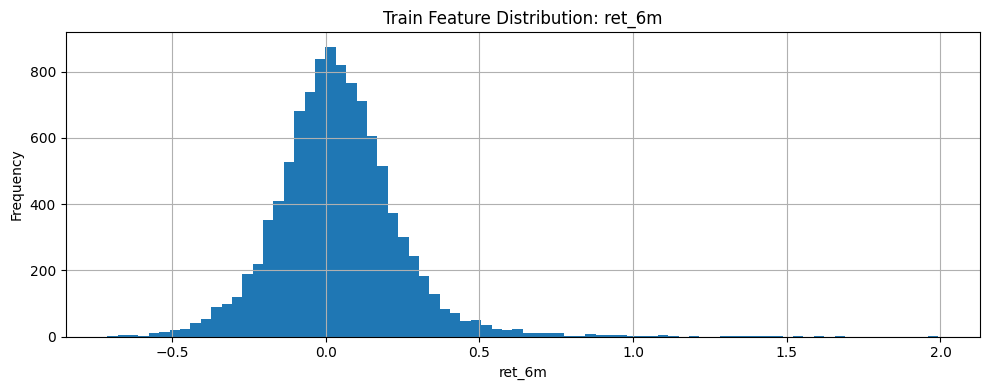

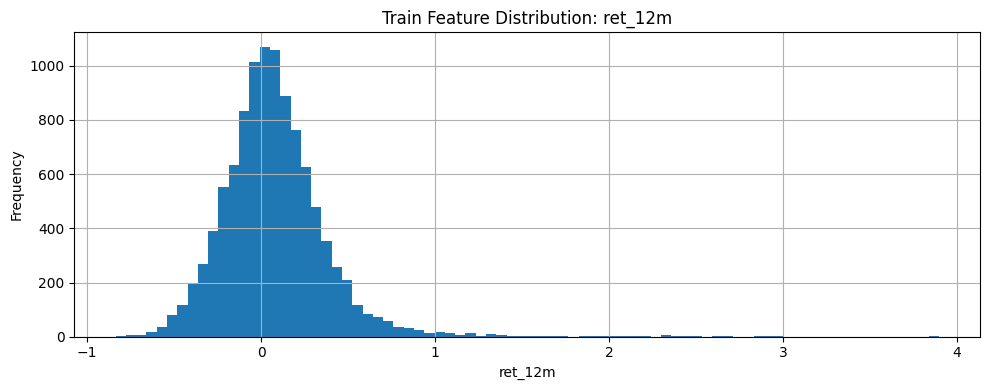

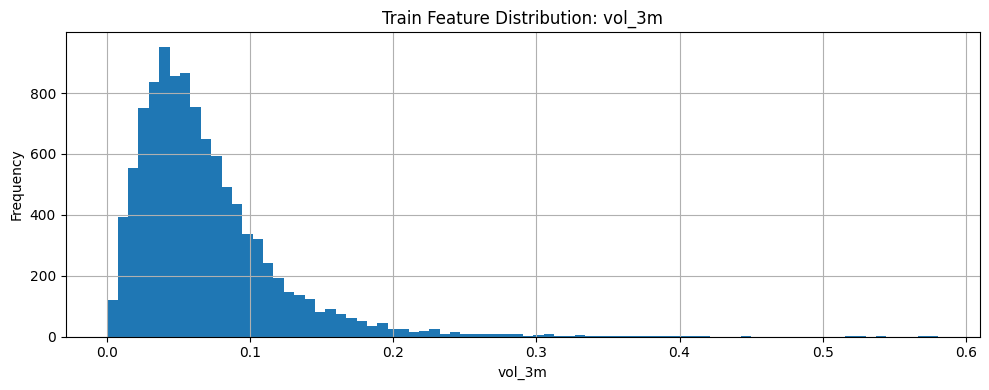

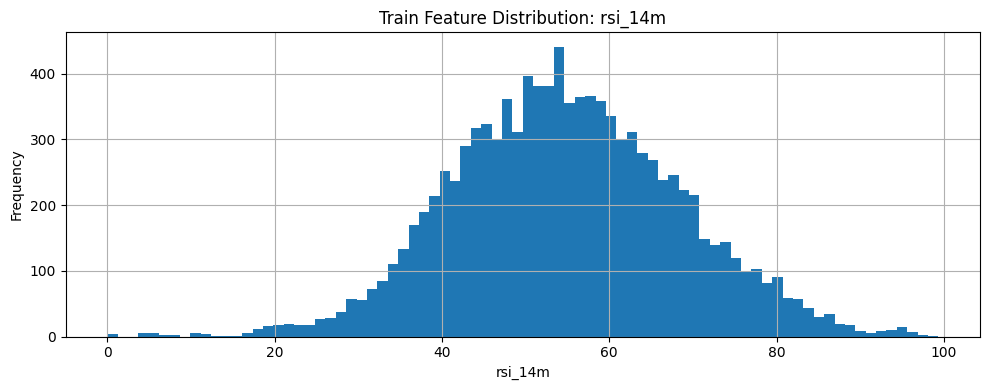

In [7]:
for col in feature_cols:
    plt.figure(figsize=(10, 4))
    plt.hist(ml_train[col], bins=80)
    plt.title(f"Train Feature Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 6. Target distribution (train vs test)

The target is next-month return.  
We compare target distributions between train and test.

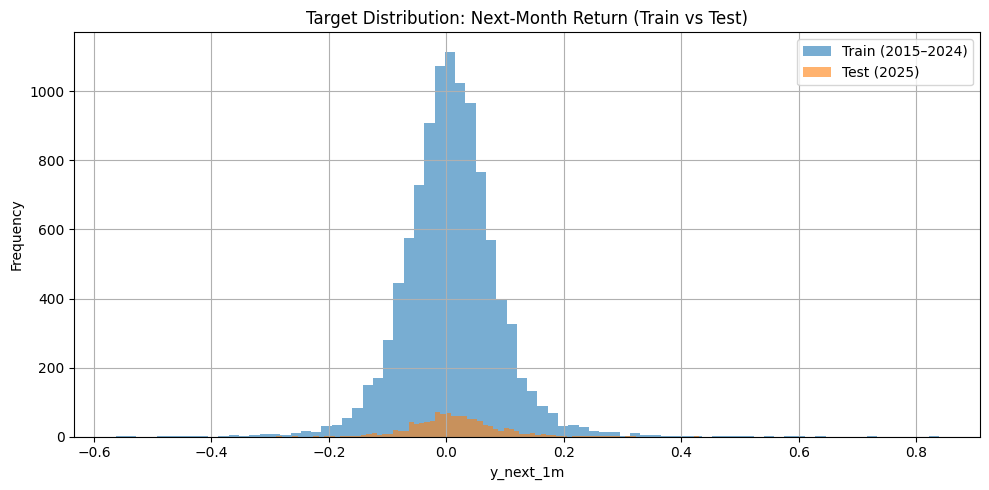

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(ml_train[target_col], bins=80, alpha=0.6, label="Train (2015–2024)")
plt.hist(ml_test[target_col], bins=80, alpha=0.6, label="Test (2025)")
plt.title("Target Distribution: Next-Month Return (Train vs Test)")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Correlation structure between features (train)

We compute a simple correlation matrix (Pearson) across features.
This helps identify redundancy (highly correlated features).

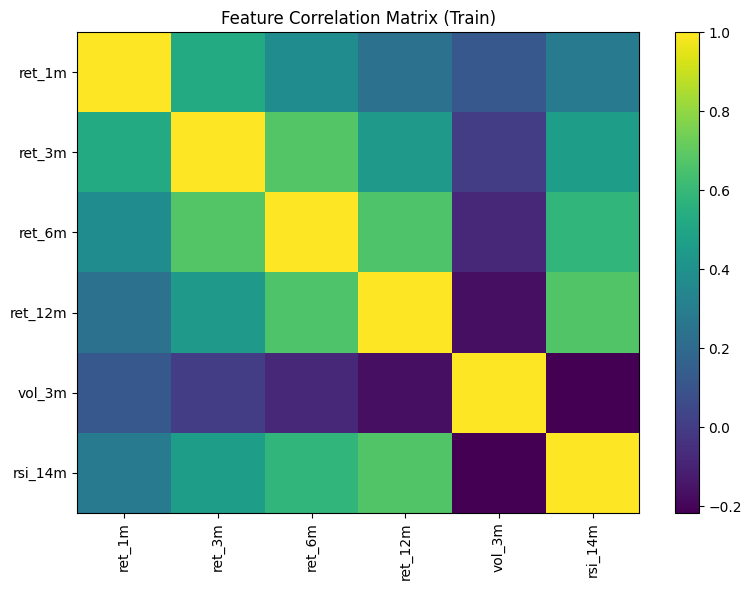

,ret_1m,ret_3m,ret_6m,ret_12m,vol_3m,rsi_14m
ret_1m,1.000000,0.529345,0.376606,0.239266,0.120351,0.279853
ret_3m,0.529345,1.000000,0.675793,0.437728,0.004925,0.460386
ret_6m,0.376606,0.675793,1.000000,0.666297,-0.075408,0.584156
ret_12m,0.239266,0.437728,0.666297,1.000000,-0.165336,0.669488
vol_3m,0.120351,0.004925,-0.075408,-0.165336,1.000000,-0.215939
rsi_14m,0.279853,0.460386,0.584156,0.669488,-0.215939,1.000000


In [9]:
corr = ml_train[feature_cols].corr(method="pearson")

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.title("Feature Correlation Matrix (Train)")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

display(corr)

## 8. Relationship between key features and target (quick check)

We compute correlations between each feature and the target.
In finance, these correlations are often small, but we check if:
- signs are reasonable
- any single feature dominates unexpectedly

In [10]:
feat_target_corr = ml_train[feature_cols + [target_col]].corr(method="spearman")[target_col].sort_values(ascending=False)
print("Spearman correlation of features with target (train):")
display(feat_target_corr)

Spearman correlation of features with target (train):


y_next_1m    1.000000
vol_3m       0.027675
rsi_14m      0.003816
ret_3m      -0.016698
ret_6m      -0.020585
ret_12m     -0.030231
ret_1m      -0.030889
Name: y_next_1m, dtype: float64

## 9. Save figures

We save a small set of figures:
- target distribution
- feature correlation matrix

Output directory: `reports/figures/eda_features/`

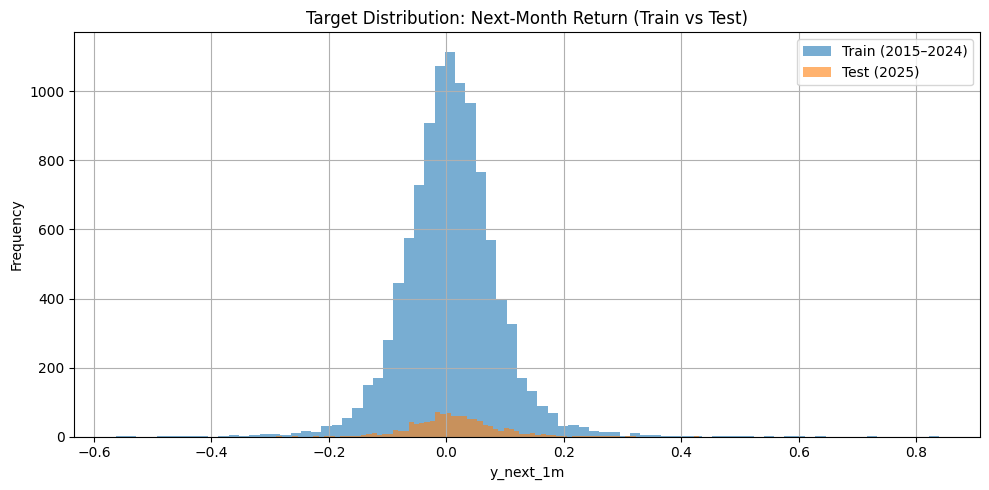

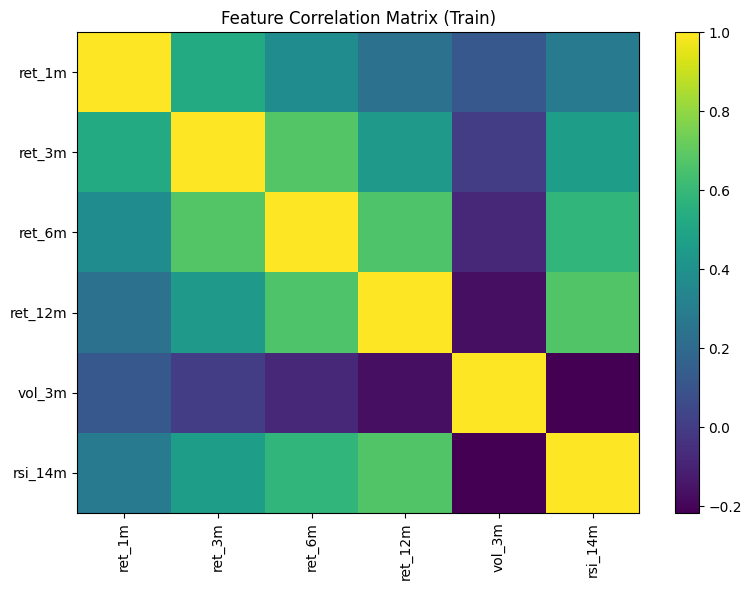

Saved figures to: reports/figures/eda_features


In [11]:
OUT_DIR = "reports/figures/eda_features"
os.makedirs(OUT_DIR, exist_ok=True)

# Target distribution
plt.figure(figsize=(10, 5))
plt.hist(ml_train[target_col], bins=80, alpha=0.6, label="Train (2015–2024)")
plt.hist(ml_test[target_col], bins=80, alpha=0.6, label="Test (2025)")
plt.title("Target Distribution: Next-Month Return (Train vs Test)")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "target_distribution_train_vs_test.png"), dpi=200)
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.title("Feature Correlation Matrix (Train)")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "feature_correlation_matrix.png"), dpi=200)
plt.show()

print("Saved figures to:", OUT_DIR)

## 10. EDA summary

This notebook confirms:
- ML dataset is properly structured (date,ticker index; features + target columns)
- feature ranges are plausible (monthly scale)
- RSI is bounded (0–100) and volatility is non-negative
- feature correlations show expected redundancy patterns
- target distribution differs slightly between train and test, as expected

Next:
- Results notebook: Baseline vs Ridge (train + 2025 test)
- Add Tree model (Random Forest) and Neural Network for model comparison